In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor


In [2]:
df=pd.read_csv("air_passengers_variable_season_2026 (1).csv")

In [3]:
df.head(15)

,Month,Passengers
0,01-01-1949,109
1,01-02-1949,129
2,01-03-1949,138
3,01-04-1949,missing
4,01-05-1949,113
5,01-06-1949,126
6,01-07-1949,135
7,01-08-1949,error
8,01-09-1949,139
9,01-10-1949,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       930 non-null    object
 1   Passengers  916 non-null    object
dtypes: object(2)
memory usage: 14.7+ KB


In [5]:
df.isnull().sum()

Month          0
Passengers    14
dtype: int64

In [6]:
df['Passengers'] = df['Passengers'].replace('?', np.nan)

In [7]:
df['Passengers'] = df['Passengers'].astype(str).str.replace(r'[^0-9.-]', '', regex=True)


In [8]:
df['Passengers'] = pd.to_numeric(df['Passengers'], errors='coerce')


In [9]:
df.loc[df['Passengers'] < 0, 'Passengers'] = np.nan


In [10]:
df['Month'] = pd.to_datetime(df['Month'], errors='coerce', dayfirst=True)


In [11]:
df.isnull().sum()

Month          0
Passengers    31
dtype: int64

In [12]:
df = df.dropna(subset=['Month'])


In [13]:
df.drop_duplicates(inplace=True)


In [14]:
df.sort_values('Month', inplace=True)

Here Month Values is object so convert it into date and time

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926 entries, 0 to 929
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       926 non-null    datetime64[ns]
 1   Passengers  895 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 21.7 KB


In [16]:
df.describe()

,Month,Passengers
count,926,895.000000
mean,1987-07-17 06:36:32.656587456,1408.402235
min,1949-01-01 00:00:00,94.000000
25%,1968-04-08 12:00:00,726.500000
50%,1987-07-16 12:00:00,1335.000000
75%,2006-10-24 06:00:00,1905.500000
max,2026-02-01 00:00:00,25080.000000
std,NaN,1508.296291


In [17]:
df['Passengers']

0        109.0
1        129.0
2        138.0
3          NaN
4        113.0
        ...   
925     2532.0
926     2740.0
927     2696.0
928    25080.0
929    23050.0
Name: Passengers, Length: 926, dtype: float64

In [18]:
df.isnull().sum()

Month          0
Passengers    31
dtype: int64

In [19]:
df['Passengers'].describe()

count      895.000000
mean      1408.402235
std       1508.296291
min         94.000000
25%        726.500000
50%       1335.000000
75%       1905.500000
max      25080.000000
Name: Passengers, dtype: float64

In [20]:
df.isnull().sum()

Month          0
Passengers    31
dtype: int64

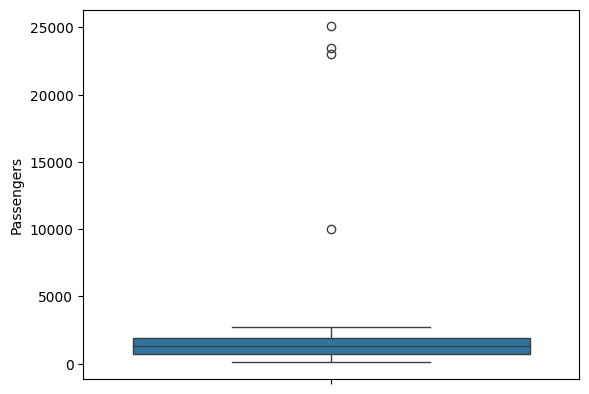

In [21]:
sns.boxplot(df['Passengers'])
plt.show()

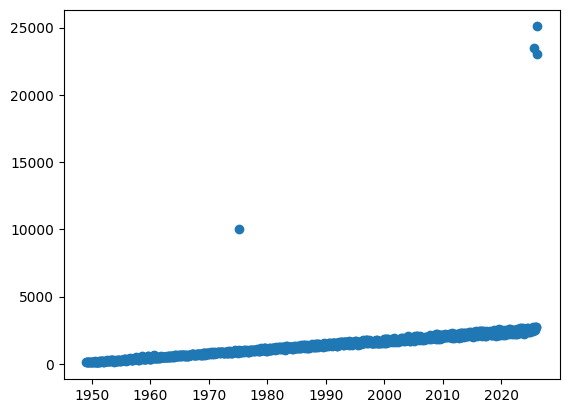

In [22]:
plt.scatter(df['Month'],df['Passengers'])
plt.show()

In [23]:
Q1 = df['Passengers'].quantile(0.25)
Q3 = df['Passengers'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Passengers'] < lower_bound) | (df['Passengers'] > upper_bound)]
print("Outliers:\n", outliers)
df = df[(df['Passengers'] >= lower_bound) & (df['Passengers'] <= upper_bound)]

Outliers:
          Month  Passengers
313 1975-02-01     10007.0
923 2025-08-01     23500.0
928 2026-01-01     25080.0
929 2026-02-01     23050.0


In [24]:
print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -1042.0
Upper: 3674.0


In [25]:
# df['Passengers']=df['Passengers'].fillna(method='ffill')
df = df.dropna(axis=1, how='all')
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [26]:
(df['Passengers']<0).sum()

np.int64(0)

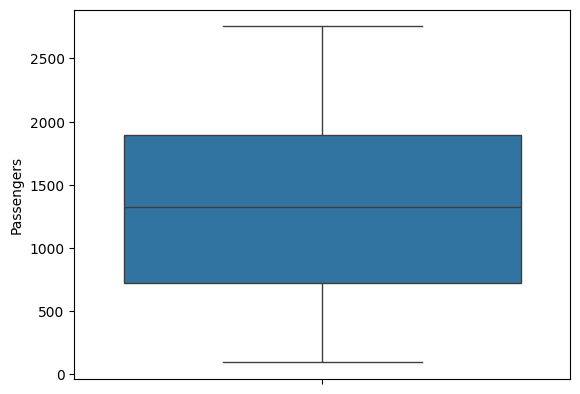

In [27]:
sns.boxplot(df['Passengers'])
plt.show()

In [28]:
df.describe()

,Month,Passengers
count,891,891.000000
mean,1987-09-20 09:35:21.212121216,1323.101010
min,1949-01-01 00:00:00,94.000000
25%,1968-11-16 00:00:00,721.500000
50%,1987-09-01 00:00:00,1324.000000
75%,2006-04-16 00:00:00,1895.000000
max,2025-12-01 00:00:00,2754.000000
std,NaN,700.442182


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 927
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       891 non-null    datetime64[ns]
 1   Passengers  891 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 20.9 KB


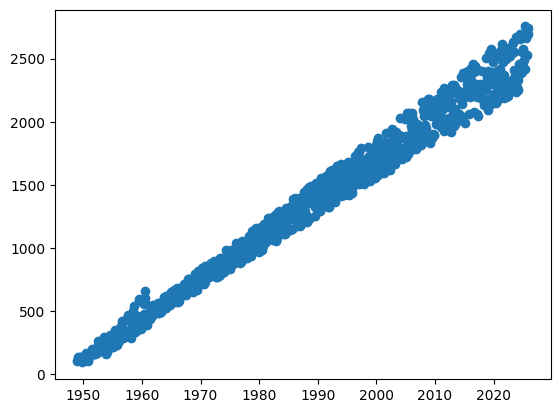

In [30]:
plt.scatter(df['Month'], df['Passengers'])
plt.show()

In [31]:
df['month']=df['Month'].dt.month
df['year']=df['Month'].dt.year

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 927
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       891 non-null    datetime64[ns]
 1   Passengers  891 non-null    float64       
 2   month       891 non-null    int32         
 3   year        891 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 27.8 KB


In [33]:
df.drop('Month',axis=1,inplace=True)

In [34]:
df.head()

,Passengers,month,year
0,109.0,1,1949
1,129.0,2,1949
2,138.0,3,1949
4,113.0,5,1949
5,126.0,6,1949


In [35]:
df.isnull().sum()

Passengers    0
month         0
year          0
dtype: int64

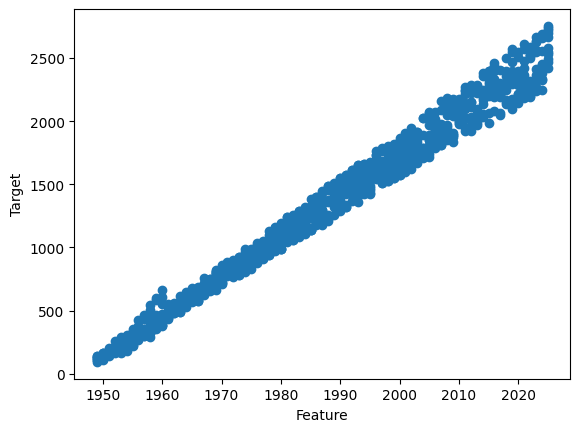

In [36]:
plt.scatter(df['year'],df['Passengers'])
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

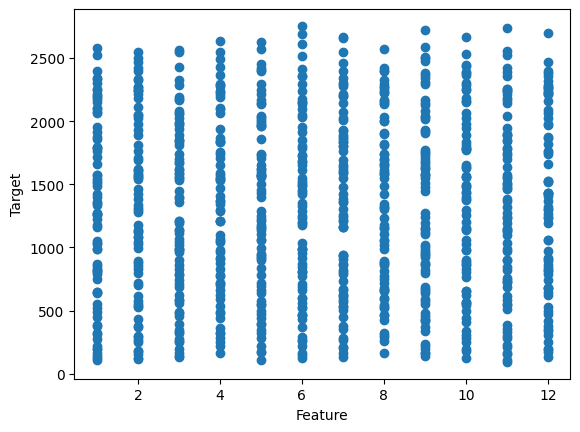

In [37]:
plt.scatter(df['month'],df['Passengers'])
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()


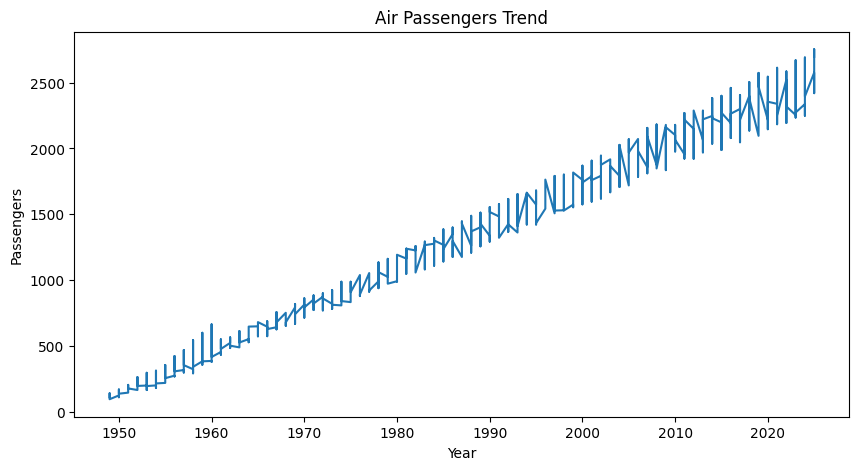

In [38]:
plt.figure(figsize=(10,5))
plt.plot(df['year'],df['Passengers'])
plt.title("Air Passengers Trend")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

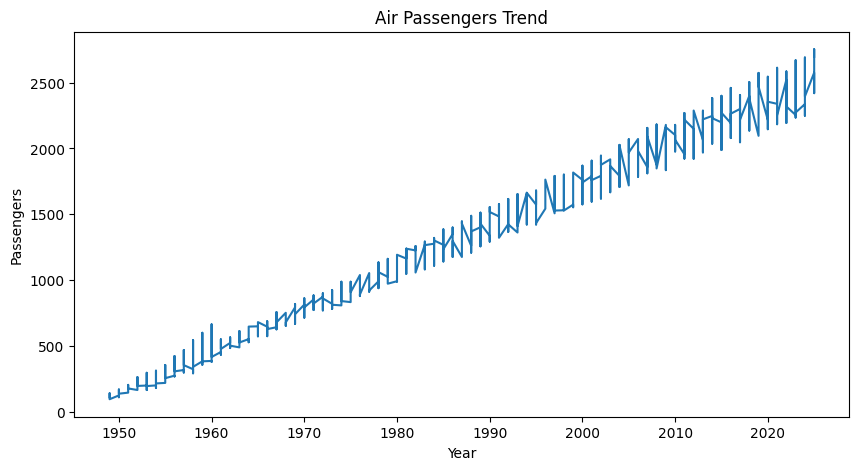

In [39]:
plt.figure(figsize=(10,5))
plt.plot(df['year'],df['Passengers'])
plt.title("Air Passengers Trend")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

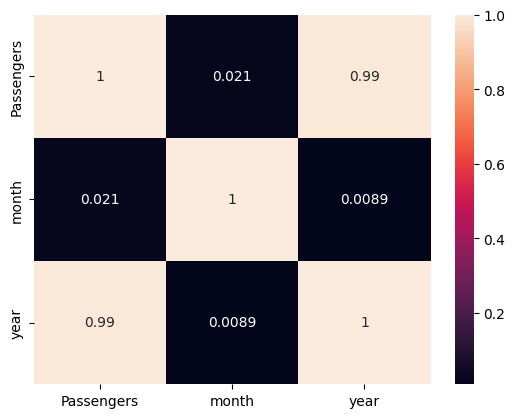

In [40]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [41]:
x=df.drop('Passengers',axis=1)
y=df['Passengers'] 

In [42]:
def evaluate(y_test,pred):

    print("MAE:",mean_absolute_error(y_test,pred))
    print("MSE:",(mean_squared_error(y_test,pred)))
    print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
    print("R2 Score:",r2_score(y_test,pred))

In [43]:
def print_results(name, model):
    print("Model:", name)
    print("Best Estimator:", model.best_estimator_)
    print("Best Parameters:", model.best_params_)
    print("Best CV Score:", model.best_score_)

In [44]:
tscv = TimeSeriesSplit(n_splits=5)

In [45]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
scores=[]
labels=[]
scores1=[]
labels1=[]

In [46]:
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(x_train)
# X_test_sc = scaler.transform(x_test)

In [47]:
lr=LinearRegression()
lr.fit(x_train,y_train)
print(lr.score(x_train,y_train))
print(lr.score(x_test,y_test))
pred_lr = lr.predict(x_test)
scores.append(r2_score(y_test,pred_lr))
labels.append("LR")
evaluate(y_test,pred_lr)        

0.9838842924639926
0.9850083770650775
MAE: 69.8815190381349
MSE: 7557.056492304887
RMSE: 86.93133205182633
R2 Score: 0.9850083770650775


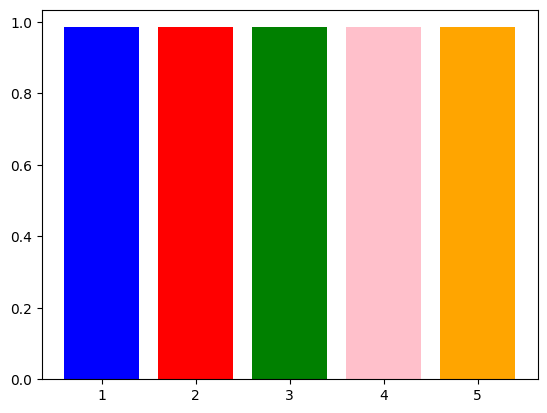

In [48]:
degress=[1,2,3,4,5]
best_score=-1
score=[]
degree=[]
colors=['blue','red','green','pink','orange']
for d in degress:
    poly=PolynomialFeatures(degree=d)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    score.append(r2_score(y_test,y_pred))
    degree.append(d)
plt.bar(degree,score,color=colors)
plt.show()

In [49]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)
model_lr = LinearRegression()
model_lr.fit(X_train_poly,y_train)
pred_poly = model_lr.predict(X_test_poly)
scores.append(r2_score(y_test,pred_poly))
labels.append("Poly")
scores1.append(r2_score(y_test,pred_poly))
labels1.append("Poly")
evaluate(y_test,pred_lr)

MAE: 69.8815190381349
MSE: 7557.056492304887
RMSE: 86.93133205182633
R2 Score: 0.9850083770650775


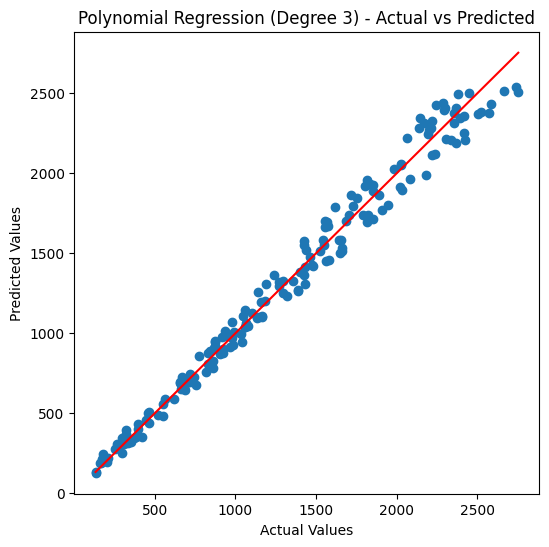

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_poly)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Polynomial Regression (Degree 3) - Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

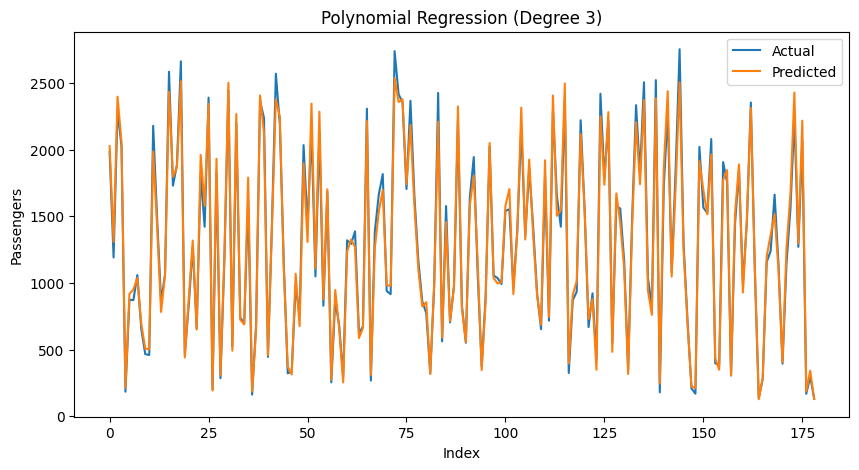

In [51]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred_poly, label="Predicted")

plt.title("Polynomial Regression (Degree 3)")
plt.xlabel("Index")
plt.ylabel("Passengers")
plt.legend()

plt.show()

In [52]:
ridge = Ridge()
ridge.fit(x_train,y_train)

pred_ridge = ridge.predict(x_test)
evaluate(y_test,pred_ridge)
scores.append(r2_score(y_test,pred_ridge))
labels.append("Ridge")

MAE: 69.88143113545401
MSE: 7557.0681118977345
RMSE: 86.9313988838195
R2 Score: 0.9850083540142303


In [53]:
param_grid = {'alpha':[0.01,0.1,1,10,100]}

grid_ridge = GridSearchCV( ridge, param_grid, cv=tscv, scoring='r2')

grid_ridge.fit(x_train,y_train)

print_results("Ridge",grid_ridge)

pred_ridge_grid = grid_ridge.predict(x_test)

evaluate(y_test,pred_ridge_grid)
scores1.append(r2_score(y_test,pred_ridge_grid))
labels1.append("Ridge-Grid")

Model: Ridge
Best Estimator: Ridge(alpha=0.01)
Best Parameters: {'alpha': 0.01}
Best CV Score: 0.9830858656296568
MAE: 69.88151815902663
MSE: 7557.056608441607
RMSE: 86.93133271980597
R2 Score: 0.9850083768346864


In [54]:
lasso = Lasso()
lasso.fit(x_train,y_train)

pred_lasso =lasso.predict(x_test)
scores.append(r2_score(y_test,pred_lasso))
labels.append("Lasso")
evaluate(y_test,pred_lasso)

MAE: 69.8614841784968
MSE: 7555.713237029924
RMSE: 86.9236057525798
R2 Score: 0.9850110418032078


In [55]:
param_grid = {'alpha':[0.001,0.01,0.1,1,10]}

grid_lasso = GridSearchCV( lasso, param_grid, cv=tscv, scoring='r2'
)

grid_lasso.fit(x_train,y_train)

print_results("Lasso",grid_lasso)

pred_lasso_grid = grid_lasso.predict(x_test)

evaluate(y_test,pred_lasso_grid)
scores1.append(r2_score(y_test,pred_lasso_grid))
labels1.append("Lasso-Grid")

Model: Lasso
Best Estimator: Lasso(alpha=0.001)
Best Parameters: {'alpha': 0.001}
Best CV Score: 0.9830858640171833
MAE: 69.88149900332235
MSE: 7557.055077073524
RMSE: 86.93132391188762
R2 Score: 0.9850083798726011


In [56]:
elastic = ElasticNet()
elastic.fit(x_train,y_train)
pred_elastic =elastic.predict(x_test)
evaluate(y_test,pred_elastic)
scores.append(r2_score(y_test,pred_elastic))
labels.append("Elastic")

MAE: 69.8415874217507
MSE: 7561.39997952344
RMSE: 86.95631075156903
R2 Score: 0.9849997604929148


In [57]:
param_grid = {
    'alpha':[0.01,0.1,1,10,0.001],
    'l1_ratio':[0.2,0.5,0.7]
}

grid_elastic = GridSearchCV( elastic, param_grid, cv=tscv, scoring='r2'
)

grid_elastic.fit(x_train,y_train)

print_results("ElasticNet",grid_elastic)

pred_elastic_grid = grid_elastic.predict(x_test)

evaluate(y_test,pred_elastic_grid)
scores1.append(r2_score(y_test,pred_elastic_grid))
labels1.append("Elastic-Grid")

Model: ElasticNet
Best Estimator: ElasticNet(alpha=0.001, l1_ratio=0.7)
Best Parameters: {'alpha': 0.001, 'l1_ratio': 0.7}
Best CV Score: 0.9830858602210928
MAE: 69.8814862367259
MSE: 7557.057982709878
RMSE: 86.93134062413785
R2 Score: 0.985008374108425


In [58]:
tree = DecisionTreeRegressor()
tree.fit(x_train,y_train)
pred_tree =tree.predict(x_test)
evaluate(y_test,pred_tree)
scores.append(r2_score(y_test,pred_tree))
labels.append("Decision-Tree")

MAE: 94.44134078212291
MSE: 17610.653631284917
RMSE: 132.70513792346142
R2 Score: 0.96506413851126


In [59]:
param_grid = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

grid_tree = GridSearchCV( tree, param_grid, cv=tscv, scoring='r2')

grid_tree.fit(x_train,y_train)

print_results("Decision Tree",grid_tree)

pred_tree_grid = grid_tree.predict(x_test)

evaluate(y_test,pred_tree_grid)
scores1.append(r2_score(y_test,pred_tree_grid))
labels1.append("Decision-Tree")

Model: Decision Tree
Best Estimator: DecisionTreeRegressor(max_depth=5, min_samples_split=10)
Best Parameters: {'max_depth': 5, 'min_samples_split': 10}
Best CV Score: 0.9788157632117847
MAE: 75.71389030638169
MSE: 8994.841846716721
RMSE: 94.8411400538644
R2 Score: 0.9821561109854677


In [60]:
rf = RandomForestRegressor()
rf.fit(x_train,y_train)
pred_rf =rf.predict(x_test)
evaluate(y_test,pred_rf)
scores.append(r2_score(y_test,pred_rf))
labels.append("Random-Forest")

MAE: 75.27787709497207
MSE: 9956.903653631285
RMSE: 99.78428560465463
R2 Score: 0.980247581141336


In [61]:
param_dist = {
    'n_estimators':[100,200,300,400],
    'max_depth':[None,5,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

random_rf = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=20,
    cv=tscv,
    scoring='r2',
    random_state=42
)

random_rf.fit(x_train,y_train)

print_results("Random Forest",random_rf)

pred_rf_rand = random_rf.predict(x_test)

evaluate(y_test,pred_rf_rand)
scores1.append(r2_score(y_test,pred_rf_rand))
labels1.append("Random-Forest")

Model: Random Forest
Best Estimator: RandomForestRegressor(max_depth=5, min_samples_leaf=2, n_estimators=400)
Best Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
Best CV Score: 0.9810961175224758
MAE: 72.97600593404664
MSE: 8147.1589195496645
RMSE: 90.26161376548541
R2 Score: 0.9838377370028728


In [62]:
svr = SVR(kernel='linear')
svr.fit(x_train,y_train)

pred_svr = svr.predict(x_test)
evaluate(y_test,pred_svr)
scores.append(r2_score(y_test,pred_svr))
labels.append("SVR")

MAE: 69.56969361662944
MSE: 7571.4123821871735
RMSE: 87.01386316091921
R2 Score: 0.9849798979756027


In [63]:

param_dist = {
    'C':[0.1,1,10,100],
    'gamma':['scale','auto'],
    'kernel':['rbf','linear']
}

random_svr = RandomizedSearchCV(
    svr,
    param_dist,
    n_iter=10,
    cv=tscv,
    scoring='r2'
)
random_svr.fit(x_train,y_train)
print_results("SVR",random_svr)
pred_svr_rand = random_svr.predict(x_test)
evaluate(y_test,pred_svr_rand)
scores1.append(r2_score(y_test,pred_svr_rand))
labels1.append("SVR")

Model: SVR
Best Estimator: SVR(C=1, kernel='linear')
Best Parameters: {'kernel': 'linear', 'gamma': 'scale', 'C': 1}
Best CV Score: 0.9824152298616402
MAE: 69.56969361662944
MSE: 7571.4123821871735
RMSE: 87.01386316091921
R2 Score: 0.9849798979756027


In [64]:
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)

pred_knn =knn.predict(x_test)
evaluate(y_test,pred_knn)
scores.append(r2_score(y_test,pred_knn))
labels.append("KNN")
# future = pd.DataFrame({
# 'month':[10],
# 'year':[2020]
# })
# future_scaled = scaler.transform(future)
# pred_future =knn.predict(future_scaled)
# print(pred_future)

MAE: 73.34860335195532
MSE: 9030.768491620114
RMSE: 95.0303556323984
R2 Score: 0.9820848400198137


In [65]:
param_grid = {
    'n_neighbors':[3,5,7,9,11]
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=tscv,
    scoring='r2'
)

grid_knn.fit(x_train,y_train)

print_results("KNN",grid_knn)

pred_knn_grid = grid_knn.predict(x_test)

evaluate(y_test,pred_knn_grid)
scores1.append(r2_score(y_test,pred_knn_grid))
labels1.append("KNN")


Model: KNN
Best Estimator: KNeighborsRegressor(n_neighbors=9)
Best Parameters: {'n_neighbors': 9}
Best CV Score: 0.9813048287190123
MAE: 70.65611421477341
MSE: 8330.107524656873
RMSE: 91.26942272555948
R2 Score: 0.9834748051514264


In [66]:
ada = AdaBoostRegressor(random_state=42)
ada.fit(x_train, y_train)

pred_ada = ada.predict(x_test)

print("\n--- AdaBoost ---")
evaluate(y_test, pred_ada)

scores.append(r2_score(y_test, pred_ada))
labels.append("AdaBoost")



--- AdaBoost ---
MAE: 77.82268804434361
MSE: 9218.263935327399
RMSE: 96.01179060577611
R2 Score: 0.9817128881895029


In [67]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(
    ada,
    param_grid,
    cv=tscv,
    scoring='r2'
)

grid_ada.fit(x_train, y_train)

print_results("AdaBoost", grid_ada)

pred_ada_grid = grid_ada.predict(x_test)

evaluate(y_test, pred_ada_grid)

Model: AdaBoost
Best Estimator: AdaBoostRegressor(learning_rate=0.1, n_estimators=200, random_state=42)
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Best CV Score: 0.978597278615435
MAE: 78.87818233512127
MSE: 9295.72698578973
RMSE: 96.41435051790646
R2 Score: 0.9815592176638024


In [68]:
ada_lr = AdaBoostRegressor(
    estimator=LinearRegression(),   
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)


ada_lr.fit(x_train, y_train)

pred_ada_lr = ada_lr.predict(x_test)

print("\n--- AdaBoost with Linear Regression ---")
evaluate(y_test, pred_ada_lr)

scores.append(r2_score(y_test, pred_ada_lr))
labels.append("AdaBoost-LR")


--- AdaBoost with Linear Regression ---
MAE: 69.90225330979109
MSE: 7543.918181241487
RMSE: 86.85573199991747
R2 Score: 0.9850344407322824


In [69]:
param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1]
}

grid_ada_lr = GridSearchCV(
    ada_lr,
    param_grid,
    cv=tscv,
    scoring='r2'
)

grid_ada_lr.fit(x_train, y_train)

print_results("AdaBoost-LR", grid_ada_lr)

pred_ada_lr_grid = grid_ada_lr.predict(x_test)

evaluate(y_test, pred_ada_lr_grid)

scores1.append(r2_score(y_test, pred_ada_lr_grid))
labels1.append("AdaBoost-LR")

Model: AdaBoost-LR
Best Estimator: AdaBoostRegressor(estimator=LinearRegression(), learning_rate=0.1,
                  random_state=42)
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best CV Score: 0.9831867532994307
MAE: 69.90225330979109
MSE: 7543.918181241487
RMSE: 86.85573199991747
R2 Score: 0.9850344407322824



--- AdaBoost with Decision Tree ---
MAE: 318.5703340517555
MSE: 135217.77323072654
RMSE: 367.71969383040465
R2 Score: 0.7317561576469523


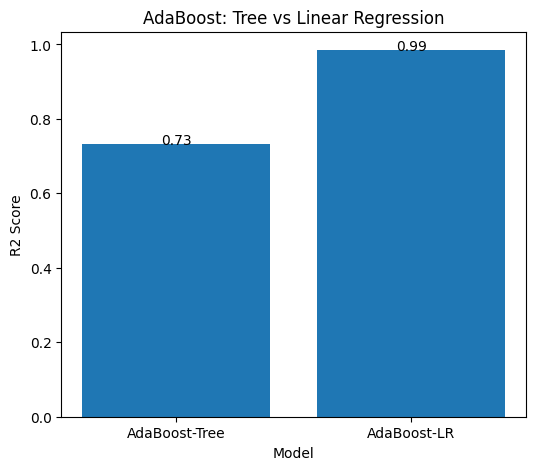

In [70]:
ada_tree = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),  # weak learner (stump)
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

ada_tree.fit(x_train, y_train)
pred_ada_tree = ada_tree.predict(x_test)

print("\n--- AdaBoost with Decision Tree ---")
evaluate(y_test, pred_ada_tree)


tree_score = r2_score(y_test, pred_ada_tree)
lr_score = r2_score(y_test, pred_ada_lr)
models = ["AdaBoost-Tree", "AdaBoost-LR"]
scores_compare = [tree_score, lr_score]

plt.figure(figsize=(6,5))
plt.bar(models, scores_compare)
plt.title("AdaBoost: Tree vs Linear Regression")
plt.xlabel("Model")
plt.ylabel("R2 Score")

for i, v in enumerate(scores_compare):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

In [71]:
base_models = {
    "Decision Tree (Stump)": DecisionTreeRegressor(max_depth=1),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=50),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

print("AdaBoost with Different Base Models (R2 Scores):\n")
for name, base_model in base_models.items():
    
    ada = AdaBoostRegressor(
        estimator=base_model,
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    )
    
    try:
    
        ada.fit(x_train, y_train)
        pred = ada.predict(x_test)
        
        score = r2_score(y_test, pred)
        print(f"{name}: {score:.5f}")
    
    except Exception as e:
        print(f"{name}:Error -> {str(e)}")

AdaBoost with Different Base Models (R2 Scores):



Decision Tree (Stump): 0.73176
Decision Tree: 0.96993
Random Forest: 0.98004
Linear Regression: 0.98503
Ridge: 0.98501
Lasso: 0.98504
SVR: 0.00015
KNN: 0.98108


In [72]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(x_train, y_train)

pred_gbr = gbr.predict(x_test)

print("\n--- Gradient Boosting ---")
evaluate(y_test, pred_gbr)

scores.append(r2_score(y_test, pred_gbr))
labels.append("GradientBoost")
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_gbr = GridSearchCV(
    gbr,
    param_grid,
    cv=tscv,
    scoring='r2'
)

grid_gbr.fit(x_train, y_train)

print_results("GradientBoost", grid_gbr)

pred_gbr_grid = grid_gbr.predict(x_test)

evaluate(y_test, pred_gbr_grid)

scores1.append(r2_score(y_test, pred_gbr_grid))
labels1.append("GradientBoost")




--- Gradient Boosting ---
MAE: 68.69303091061957
MSE: 7502.650715575285
RMSE: 86.6178429399814
R2 Score: 0.9851163067717089
Model: GradientBoost
Best Estimator: GradientBoostingRegressor(random_state=42)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.9798692566945038
MAE: 68.69303091061957
MSE: 7502.650715575285
RMSE: 86.6178429399814
R2 Score: 0.9851163067717089


In [73]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)

pred_xgb = xgb.predict(x_test)

print("\n--- XGBoost ---")
evaluate(y_test, pred_xgb)

scores.append(r2_score(y_test, pred_xgb))
labels.append("XGBoost")
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

random_xgb = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=10,
    cv=tscv,
    scoring='r2',
    random_state=42
)

random_xgb.fit(x_train, y_train)

print_results("XGBoost", random_xgb)

pred_xgb_rand = random_xgb.predict(x_test)

evaluate(y_test, pred_xgb_rand)

scores1.append(r2_score(y_test, pred_xgb_rand))
labels1.append("XGBoost")


--- XGBoost ---
MAE: 73.9045760511686
MSE: 10422.80468098464
RMSE: 102.09213819381314
R2 Score: 0.979323330735879
Model: XGBoost
Best Estimator: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
Best Parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score: 0.978742137343608

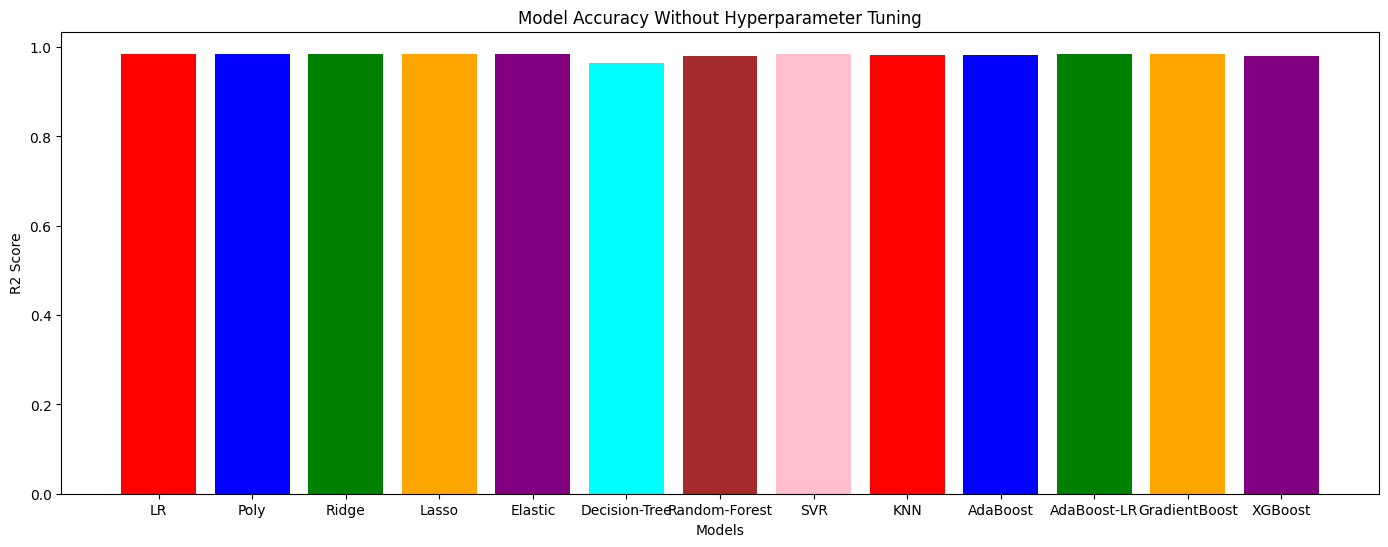

In [74]:
colors = ['red','blue','green','orange','purple','cyan','brown','pink']
plt.figure(figsize=(17,6))
plt.bar(labels,scores,color=colors)
plt.title("Model Accuracy Without Hyperparameter Tuning")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.savefig('WithoutTuning.jpg')
plt.show()

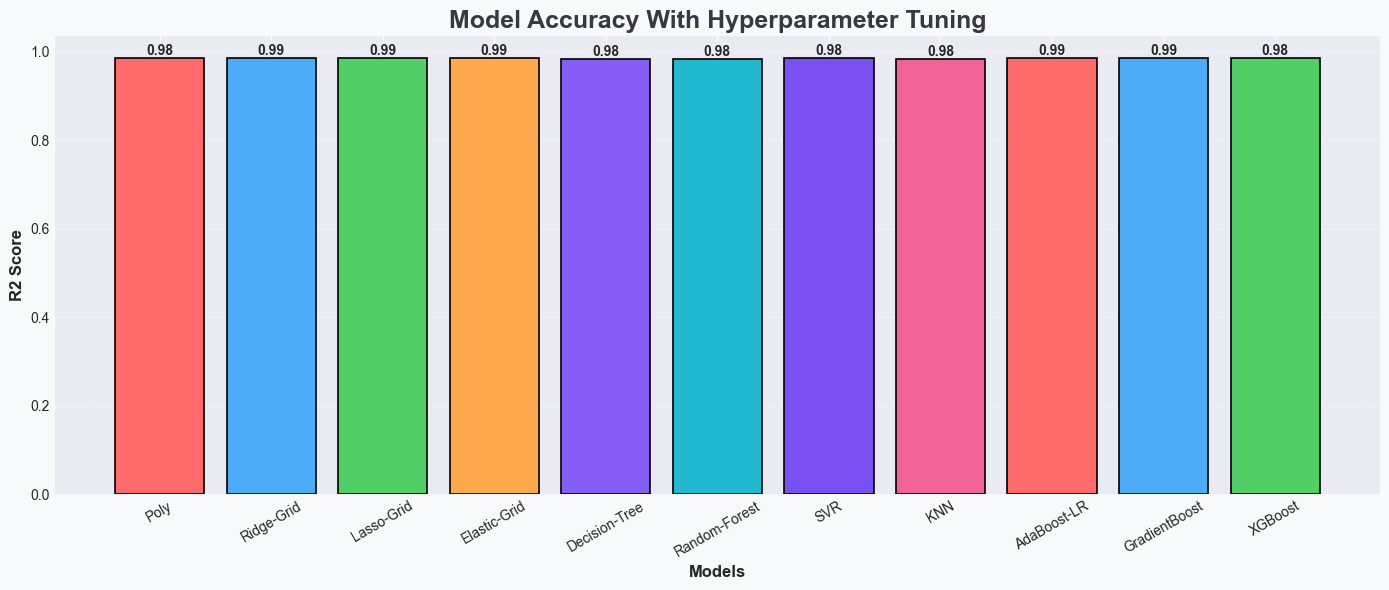

In [75]:
plt.style.use('seaborn-v0_8-darkgrid') 

colors = ['#ff6b6b','#4dabf7','#51cf66','#ffa94d','#845ef7','#22b8cf','#7950f2','#f06595']

plt.figure(figsize=(14,6), facecolor='#f8f9fa')

bars = plt.bar(labels1, scores1, color=colors, edgecolor='black', linewidth=1.2)

plt.title("Model Accuracy With Hyperparameter Tuning",
          fontsize=18, fontweight='bold', color='#343a40')

plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("R2 Score", fontsize=12, fontweight='bold')
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('WithTuning_styled.jpg', dpi=300)
plt.show()

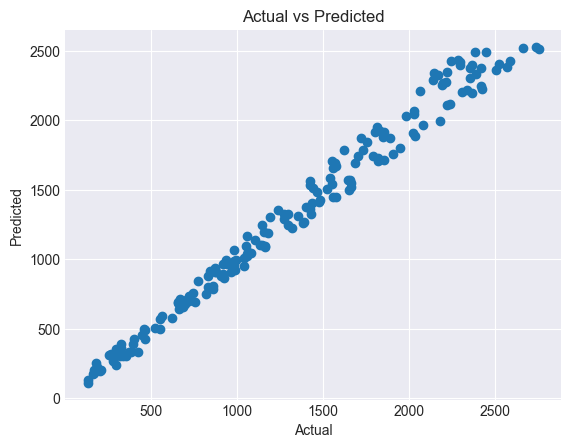

In [76]:
plt.scatter(y_test,pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

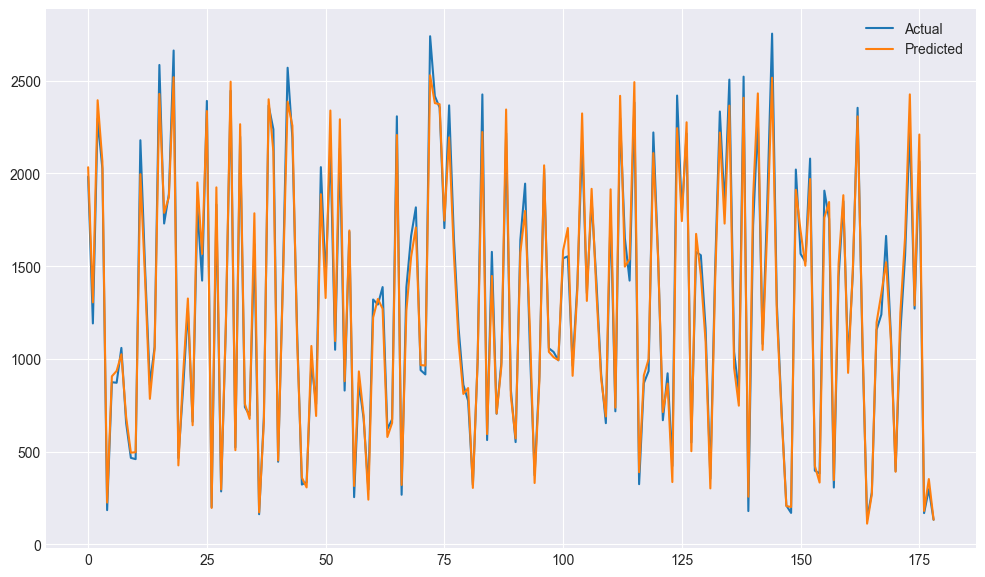

In [77]:
plt.figure(figsize=(12,7))
plt.plot(y_test.values,label="Actual")
plt.plot(pred_lr,label="Predicted")

plt.legend()
plt.show()

In [78]:
import pickle
pickle.dump(lr, open("model1.pkl", "wb"))

In [79]:
df.to_csv("new_air_passangers.csv",index=False)